# Próg decyzyjny (threshold tuning)

Regulacja **progu decyzyjnego** (ang. **threshold tuning**) to technika, która polega na zmianie domyślnego progu, powyżej którego klasyfikator przypisuje obserwację do klasy pozytywnej (np. fraud, readmisja, choroba itp.).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import (
    f1_score, precision_score, recall_score, make_scorer,
    classification_report, confusion_matrix
)

**Dane - Germin Credit Data** (do wyboru)

In [2]:
from sklearn.datasets import fetch_openml

In [3]:
data = fetch_openml("credit-g", version=1, as_frame=True)
X = data.data.select_dtypes(include='number')  # tylko cechy liczbowe dla ułatwienia
y = data.target
dataset = "credit-g"
class_names = y.unique().tolist()
print(class_names)
y = y.map({'good': 0, 'bad': 1}) # mapowanie ułatwiające dalsze analizy

['good', 'bad']


**Dane - Breast cancer** (do wyboru)

In [4]:
data = load_breast_cancer()
X = data.data
y = data.target
dataset = "breast_cancer"

**Podział i skalowanie**:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model bazowy** (regresja logistyczna):

In [6]:
base_model = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)
base_model.fit(X_train, y_train)

# predict_proba(X_test) zwraca prawdopodobieństwa przynależności do obu klas dla każdego przykładu z zestawu testowego X_test.
# [:, 1] wybiera prawdopodobieństwo klasy pozytywnej (np. klasa 1).
y_probs_base = base_model.predict_proba(X_test)[:, 1]

# Jeśli prawdopodobieństwo ≥ 0.5, przypisuje klasę 1; w przeciwnym razie – 0.
# astype(int) konwertuje wartości logiczne na liczby całkowite (True → 1, False → 0).
y_pred_default = (y_probs_base >= 0.5).astype(int)

**Model z doborem progu**. 

Strojenie progu klasyfikacji (threshold tuning) dla regresji logistycznej, aby zmaksymalizować miarę F1-score:
* Tworzymy klasyfikator regresji logistycznej z automatycznym doborem progu.
* Dobieramy próg tak, aby zoptymalizować F1-score, zamiast używać domyślnego 0.5.
* Klasyfikujemy dane testowe według najlepszego znalezionego progu.

In [7]:
scorer = make_scorer(f1_score, pos_label=1)
tuned_model = TunedThresholdClassifierCV(estimator=base_model, scoring=scorer)
tuned_model.fit(X_train, y_train)

# j.w.
y_probs_tuned = tuned_model.predict_proba(X_test)[:, 1]
best_threshold = tuned_model.best_threshold_
y_pred_tuned = (y_probs_tuned >= best_threshold).astype(int)

**Wyniki: domyślny próg**:

In [8]:
print("=== Wyniki dla domyślnego progu (0.5) ===")
print(f"F1-score: {f1_score(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_default):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_default, digits=4))

=== Wyniki dla domyślnego progu (0.5) ===
F1-score: 0.9645
Precision: 0.9855
Recall: 0.9444

Classification report:
              precision    recall  f1-score   support

           0     0.9111    0.9762    0.9425        42
           1     0.9855    0.9444    0.9645        72

    accuracy                         0.9561       114
   macro avg     0.9483    0.9603    0.9535       114
weighted avg     0.9581    0.9561    0.9564       114



**Wyniki: optymalny próg**:

In [9]:
print(f"\n=== TunedThresholdClassifierCV: najlepszy próg = {best_threshold:.4f} ===")
print(f"F1-score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_tuned, digits=4))


=== TunedThresholdClassifierCV: najlepszy próg = 0.4040 ===
F1-score: 0.9861
Precision: 0.9861
Recall: 0.9861

Classification report:
              precision    recall  f1-score   support

           0     0.9762    0.9762    0.9762        42
           1     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



**Wykres metryk**:

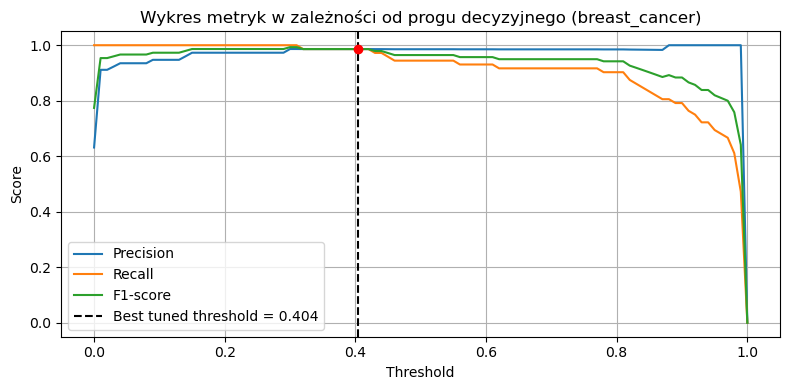

In [10]:
thresholds = np.linspace(0.0, 1.0, 101)
precision_vals, recall_vals, f1_vals = [], [], []

for t in thresholds:
    y_pred = (y_probs_base >= t).astype(int)
    precision_vals.append(precision_score(y_test, y_pred, zero_division=0))
    recall_vals.append(recall_score(y_test, y_pred))
    f1_vals.append(f1_score(y_test, y_pred))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision_vals, label='Precision')
plt.plot(thresholds, recall_vals, label='Recall')
plt.plot(thresholds, f1_vals, label='F1-score')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Best tuned threshold = {best_threshold:.3f}')
plt.scatter([best_threshold], [f1_score(y_test, y_pred_tuned)], color='red', zorder=5)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title(f'Wykres metryk w zależności od progu decyzyjnego ({dataset})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Więcej:

* Post-tuning the decision threshold for cost-sensitive learning: https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html#sphx-glr-auto-examples-model-selection-plot-cost-sensitive-learning-py

* Tuning the decision threshold for class prediction: https://scikit-learn.org/stable/modules/classification_threshold.html 



# Krzywe uczenia (learning curve)

**Krzywa uczenia (ang. *learning curve*)** to narzędzie służące do oceny, jak zmienia się wydajność modelu uczenia maszynowego w zależności od liczby przykładów uczących. Pozwala na:

* wykrycie **niedouczenia** (underfittingu), gdy model osiąga niską dokładność nawet na zbiorze treningowym,
* wykrycie **przeuczenia** (overfittingu), gdy model ma wysoką dokładność na treningu, ale słabą na walidacji,
* ocenę, czy **zwiększenie liczby danych** przyniosłoby poprawę.

W scikit-learn funkcja `learning_curve` oblicza metryki dla rosnących rozmiarów zbioru treningowego. Do wizualizacji wyników służy `LearningCurveDisplay.from_estimator`.

---

Wykres:

* **Krzywa treningowa**: jak model uczy się na coraz większym zbiorze danych.
* **Krzywa walidacyjna**: jak rośnie jego ogólna zdolność do generalizacji.
* **Rozrzut** (pasy cieniowania): informacja o stabilności wyniku.

---

**Opis zbioru `digits` (scikit-learn)**

Zbiór `digits` to klasyczny, niewielki zbiór danych do klasyfikacji obrazów cyfr. Zawiera:

* **1797 próbek** obrazów cyfr (`0`–`9`)
* Każdy obraz to **8×8 pikseli** (czyli 64 cechy), wartości pikseli od `0` do `16`
* Celem jest **rozpoznanie cyfr** zapisanych odręcznie (klasyfikacja wieloklasowa)
Wymiary:

* `X.shape = (1797, 64)`
* `y.shape = (1797,)` (etykiety klas od 0 do 9)

---

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

from sklearn.model_selection import learning_curve
from sklearn.model_selection import LearningCurveDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [12]:
# Dane
X, y = load_digits(return_X_y=True)
cv = StratifiedKFold(n_splits=5)
train_sizes = np.linspace(0.1, 1.0, 10)

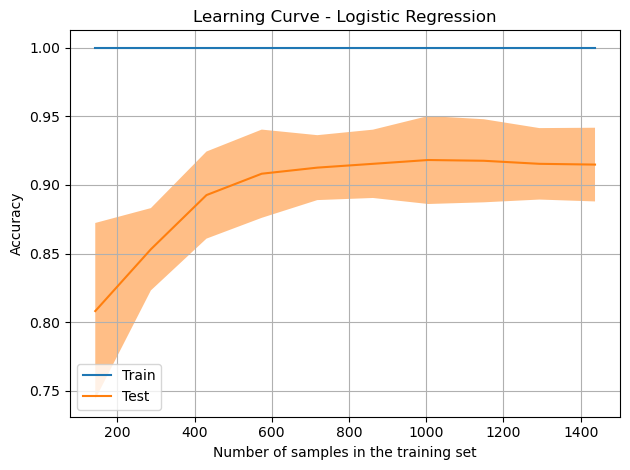

In [13]:
# Model: regresja logistyczna
model = LogisticRegression(max_iter=1000, solver='lbfgs')

# Krzywa uczenia
cv = StratifiedKFold(n_splits=5)
train_sizes = np.linspace(0.1, 1.0, 10)

# Rysowanie krzywej
LearningCurveDisplay.from_estimator(
    estimator=model,
    X=X,
    y=y,
    train_sizes=train_sizes,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

plt.title("Learning Curve - Logistic Regression")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretacja**:
  
* **Model**: Regresja logistyczna (`LogisticRegression`)
* **Dane**: Zbiór `digits` — rozpoznawanie cyfr (klasyfikacja wieloklasowa)
* **Metryka**: Dokładność klasyfikacji (`accuracy`)
* **Walidacja**: 5-krotna walidacja krzyżowa (`StratifiedKFold`)
* **Zakres danych uczących**: Od 10% do 100% zbioru

---

1. **Krzywa treningowa**:

   * Startuje wysoko (np. >0.99) przy małej liczbie próbek — model łatwo „zapamiętuje” dane.

2. **Krzywa walidacyjna**:

   * Zaczyna niżej (np. ok. 0.80) przy małej liczbie danych, ponieważ model generalizuje słabo przy ograniczonym treningu.
   * **Stopniowo rośnie**, pokazując, że model uczy się lepiej wraz ze wzrostem liczby przykładów uczących.
   * W końcu **osiąga plateau** — dalsze zwiększanie zbioru treningowego nie poprawia znacząco wyników.

---

**Wnioski**:

* **Brak silnego overfittingu**: odległość między krzywą treningową a walidacyjną nie jest drastyczna.
* **Model dobrze generalizuje**: walidacja osiąga wysoki poziom (np. >0.9), z niewielkim rozrzutem.
* **Zwiększanie danych może dać niewielką poprawę**, ale korzyści maleją — osiągnięto prawdopodobnie punkt nasycenia modelu.

---

Porównajmy różne modele:

In [14]:
# Modele
models = {
    'Regresja logistyczna': LogisticRegression(max_iter=1000, solver='lbfgs'),
    'Drzewo decyzyjne': DecisionTreeClassifier(random_state=42),  # brak ograniczeń -> może być przeuczenie
    'Drzewo decyzyjne (głębokość = 1)': DecisionTreeClassifier(max_depth=1, random_state=42),  # bardzo prosty model, niedouczenie
    'Gaussian Naive Bayes': GaussianNB() # niedopasowanie założeń - niezależność cech
}

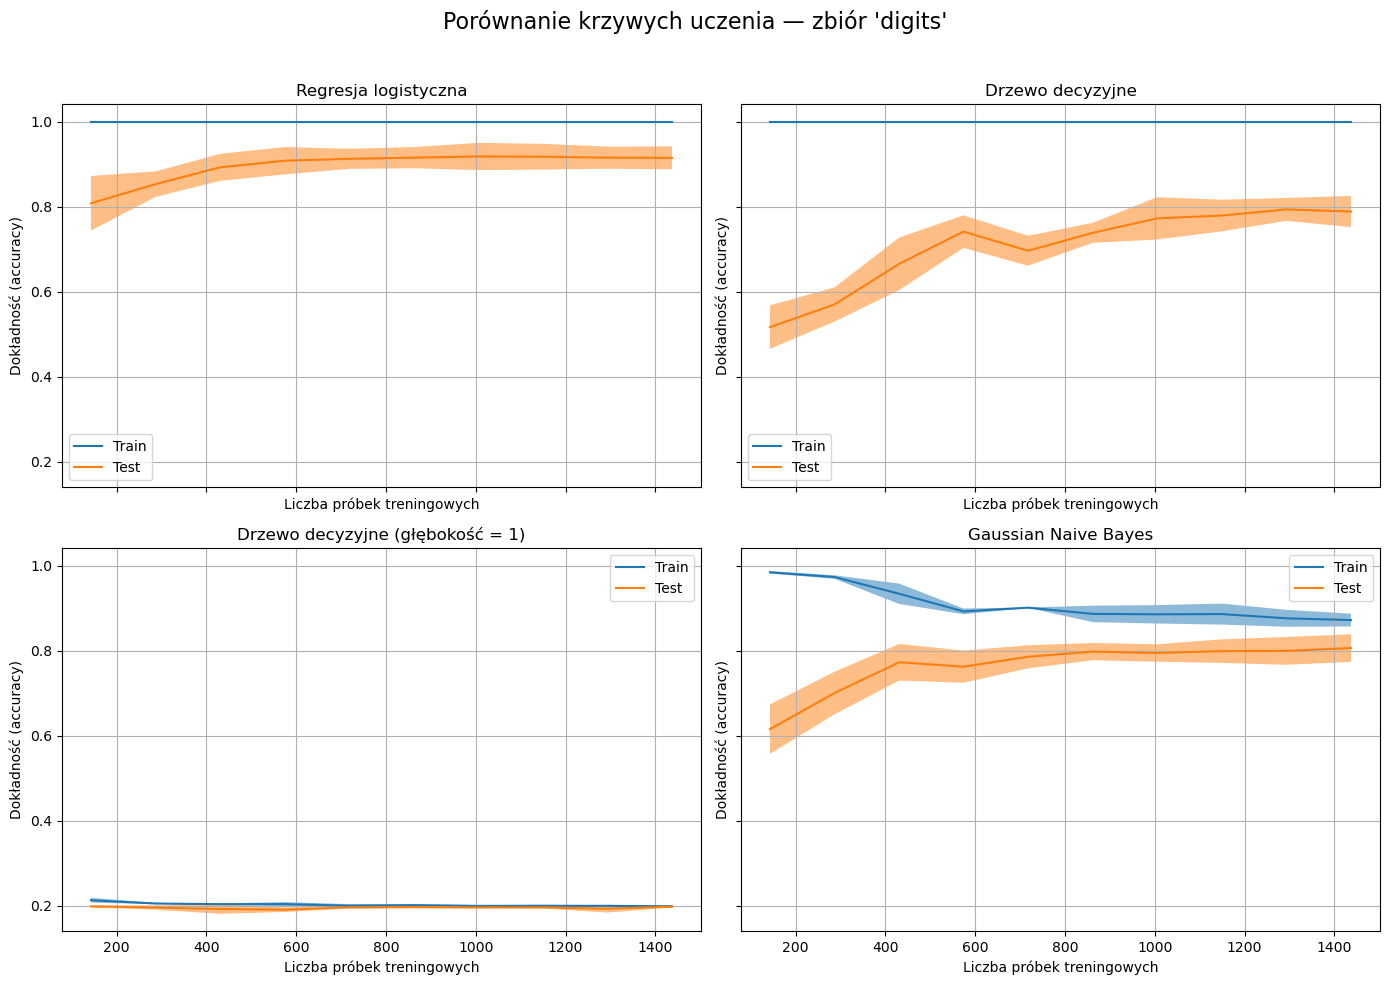

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Rysowanie każdego modelu
for ax, (name, model) in zip(axes.ravel(), models.items()):
    LearningCurveDisplay.from_estimator(
        estimator=model,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Liczba próbek treningowych")
    ax.set_ylabel("Dokładność (accuracy)")
    ax.grid(True)

plt.suptitle("Porównanie krzywych uczenia — zbiór 'digits'", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

lub z wykorzystaniem: `learning_curv`:

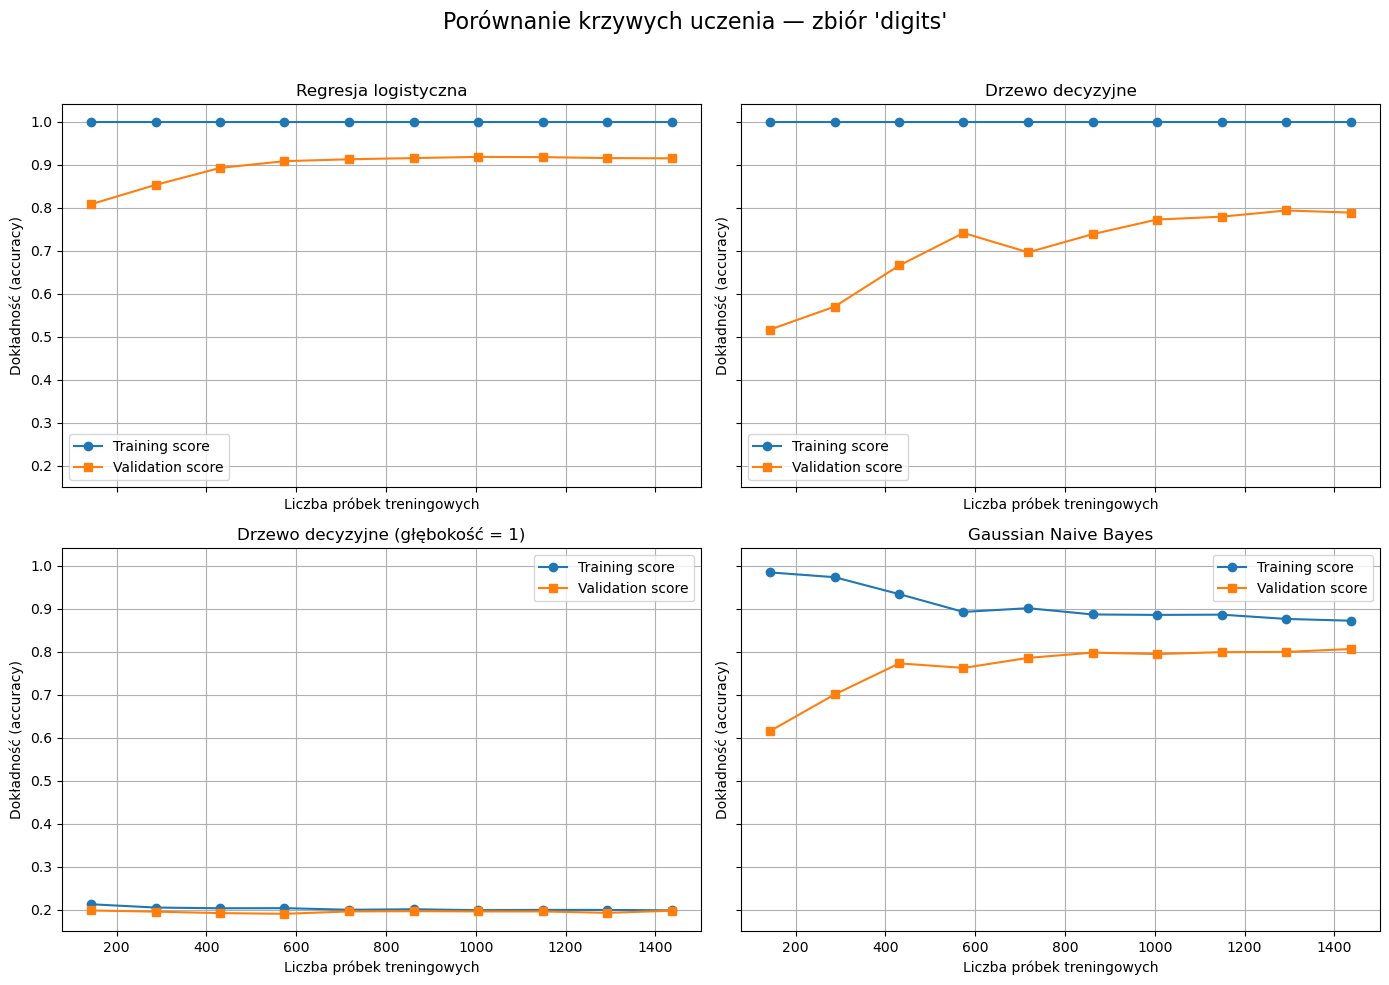

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Rysowanie każdego modelu
for ax, (name, model) in zip(axes.ravel(), models.items()):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    ax.plot(train_sizes_abs, train_mean, label='Training score', marker='o')
    ax.plot(train_sizes_abs, val_mean, label='Validation score', marker='s')

    ax.set_title(name)
    ax.grid(True)
    ax.set_xlabel("Liczba próbek treningowych")
    ax.set_ylabel("Dokładność (accuracy)")
    ax.legend()

plt.suptitle("Porównanie krzywych uczenia — zbiór 'digits'", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Interpretacja**:

* **Regresja logistyczna**: dobre dopasowanie, niewielka luka, dobra generalizacja.
* **Drzewo decyzyjne (bez ograniczeń)**: silny overfitting — prawie 100% na treningu, ale niższy wynik walidacyjny.
* **Drzewo głębokości 1**: underfitting — niska dokładność nawet na zbiorze treningowym.
* **GaussianNB**: umiarkowana skuteczność, stabilna, ale niższa dokładność z powodu niedopasowania do danych.

Oto szczegółowe wyjaśnienie interpretacji wyników krzywych uczenia dla każdego z czterech modeli:

---

**1. Regresja logistyczna**

**Dobre dopasowanie, niewielka luka, dobra generalizacja.**

* **Krzywa treningowa i walidacyjna są blisko siebie**, co oznacza, że model nie przeucza się (brak dużej różnicy między wynikami na treningu a walidacji).
* **Obie krzywe osiągają wysoką dokładność (\~0.9 i więcej)**, co świadczy o tym, że model dobrze odwzorowuje zależności w danych.
* **Stabilny przebieg krzywej walidacyjnej** sugeruje, że model dobrze radzi sobie z generalizacją – potrafi trafnie klasyfikować dane, których wcześniej nie widział.

**Wniosek:** regresja logistyczna to prosty, ale skuteczny model liniowy, który działa dobrze, gdy dane mają strukturę nadającą się do separacji liniowej (jak w zbiorze `digits` po redukcji wymiarów).

---

**2. Drzewo decyzyjne (bez ograniczeń głębokości)**

**Silny overfitting — prawie 100% na treningu, ale niższy wynik walidacyjny.**

* **Trening accuracy ≈ 100%** — drzewo perfekcyjnie zapamiętuje dane treningowe (nawet szum).
* **Validation accuracy jest znacznie niższa i niestabilna** — model nie generalizuje dobrze, bo dostosował się zbyt dokładnie do konkretnych danych uczących.
* **Szeroka luka między krzywymi** wskazuje na przeuczenie (**overfitting**).

**Wniosek:** drzewo bez ograniczeń głębokości jest zbyt złożone. Dobrze "zapamiętuje" dane treningowe, ale nie uczy się ogólnych wzorców.

---

**3. Drzewo decyzyjne z maksymalną głębokością = 1**

**Underfitting — niska dokładność nawet na zbiorze treningowym.**

* **Trening accuracy jest niska (\~0.6–0.7)** — model jest zbyt prosty, by uchwycić nawet wzorce obecne w danych uczących.
* **Validation accuracy również niska i podobna do treningowej** — nie występuje overfitting, ale model też nie ma wystarczającej mocy predykcyjnej.
* **Brak poprawy wraz ze wzrostem danych** — model jest zbyt ograniczony.

**Wniosek:** zbyt mała głębokość drzewa powoduje **niedouczenie** (**underfitting**), nawet jeśli dostarczymy mu dużo danych.

---

**4. Gaussian Naive Bayes**

**Umiarkowana skuteczność, stabilna, ale niższa dokładność z powodu niedopasowania do danych.**

* **Training accuracy umiarkowana (\~0.8), ale nie rośnie znacząco z liczbą danych** — model bazuje na uproszczonym założeniu niezależności cech.
* **Validation accuracy jest niższa, ale stabilna** — świadczy to o tym, że model generalizuje w sposób przewidywalny, ale ograniczony.
* **Brak dużej luki między krzywymi** nie oznacza, że model działa dobrze — tylko że **błędy wynikają z uproszczenia modelu**, a nie z nadmiernego dopasowania.

**Wniosek:** `GaussianNB` ma ograniczoną reprezentatywność dla złożonych zbiorów, takich jak obrazy cyfr, gdzie cechy są skorelowane (np. sąsiednie piksele).

---

# Krzywa walidacyjne (Validation Curve)

**Validation curve** (krzywa walidacyjna) pokazuje, jak zmienia się wydajność modelu w zależności od wartości **jednego z jego hiperparametrów**.

Pozwala odpowiedzieć na pytania:

* Czy model jest **zbyt prosty** (underfitting) lub **zbyt złożony** (overfitting)?
* Jak dobrać **optymalną wartość hiperparametru** (np. głębokość drzewa, C, gamma)?

---

W scikit-learn można wygenerować dane krzywej walidacyjnej funkcją `validation_curve()`, a zwizualizować je za pomocą `ValidationCurveDisplay.from_estimator()`.

---

Poniżej przykłady Validation Curve — różne modele, różne hiperparametry:

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import ValidationCurveDisplay

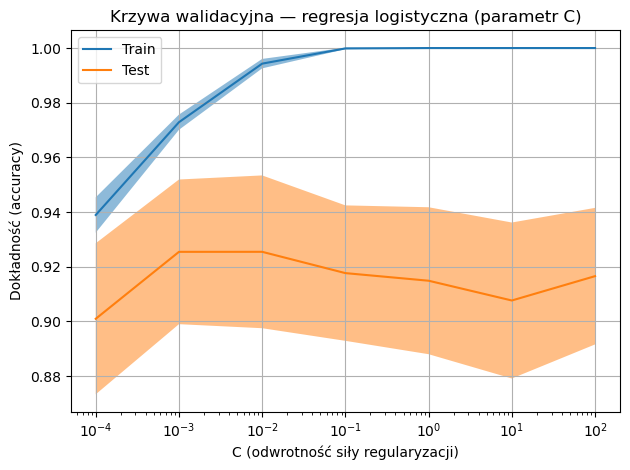

In [18]:
# Dane
X, y = load_digits(return_X_y=True)

# Model i parametry
model = LogisticRegression(max_iter=1000)
param_name = "C"
param_range = np.logspace(-4, 2, 7)  # np. [0.0001, ..., 100]

# Walidacja krzyżowa
cv = StratifiedKFold(n_splits=5)

# Wykres
ValidationCurveDisplay.from_estimator(
    estimator=model,
    X=X,
    y=y,
    param_name=param_name,
    param_range=param_range,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

plt.title("Krzywa walidacyjna — regresja logistyczna (parametr C)")
plt.xlabel("C (odwrotność siły regularyzacji)")
plt.ylabel("Dokładność (accuracy)")
plt.xscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

I porównanie kilku modeli i hiperparametrów:

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import ValidationCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

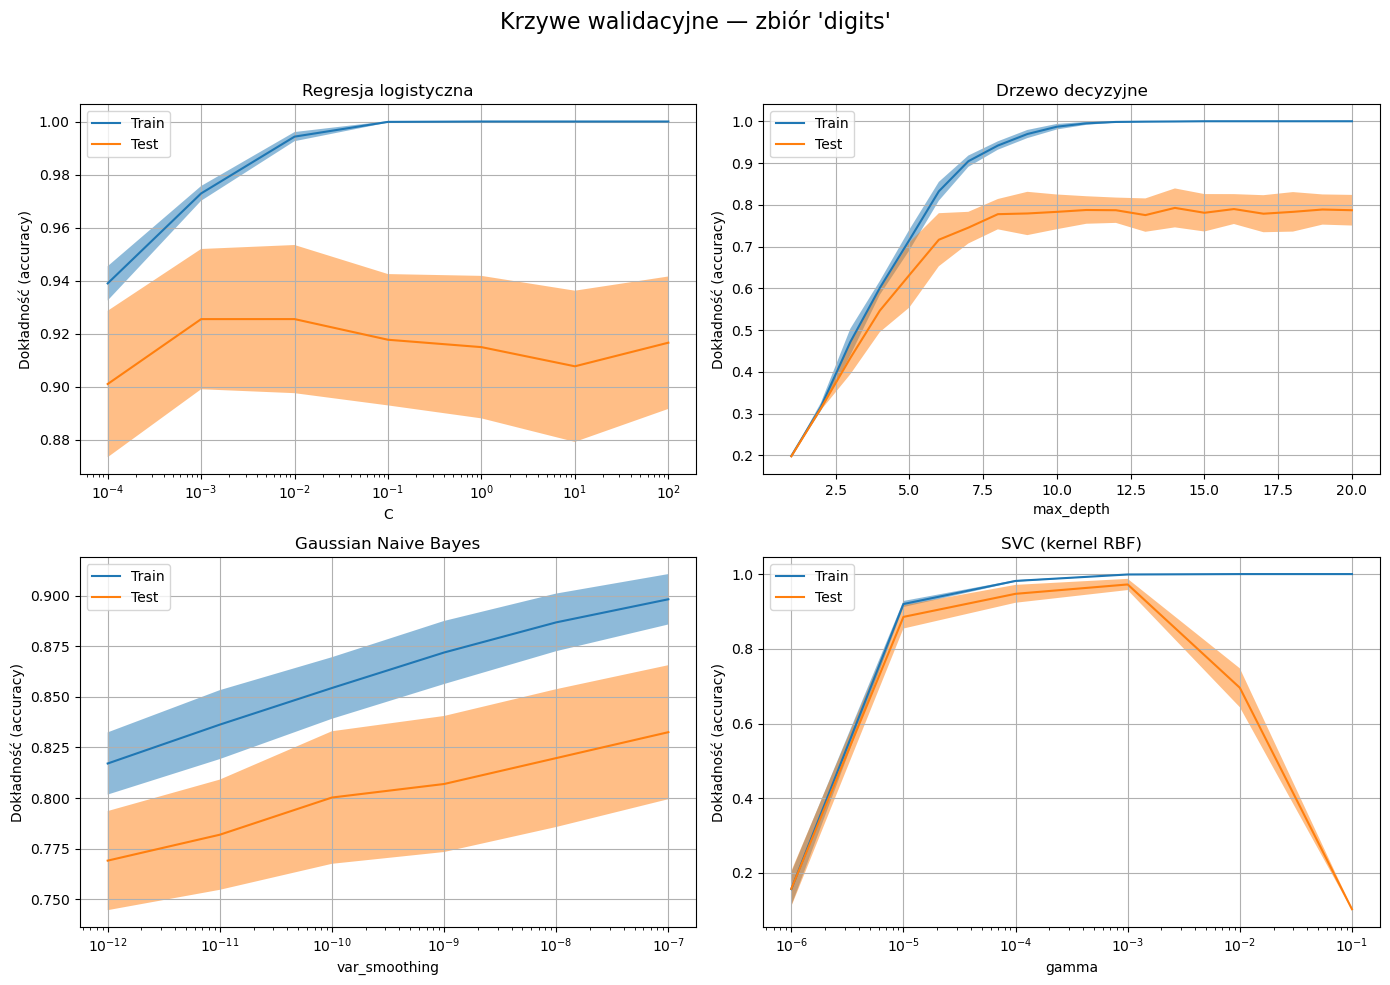

In [20]:
# Dane i konfiguracja
X, y = load_digits(return_X_y=True)
cv = StratifiedKFold(n_splits=5)

# Parametry i modele
models_params = [
    (
        "Regresja logistyczna",
        LogisticRegression(max_iter=1000),
        "C",
        np.logspace(-4, 2, 7)
    ),
    (
        "Drzewo decyzyjne",
        DecisionTreeClassifier(),
        "max_depth",
        np.arange(1, 21)
    ),
    (
        "Gaussian Naive Bayes",
        GaussianNB(),
        "var_smoothing",
        np.logspace(-12, -7, 6)
    ),
    (
        "SVC (kernel RBF)",
        SVC(),
        "gamma",
        np.logspace(-6, -1, 6)
    )
]

# Tworzenie subplotów
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rysowanie krzywych walidacyjnych
for ax, (title, model, param_name, param_range) in zip(axes.ravel(), models_params):
    ValidationCurveDisplay.from_estimator(
        estimator=model,
        X=X,
        y=y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(param_name)
    ax.set_ylabel("Dokładność (accuracy)")
    ax.grid(True)

plt.suptitle("Krzywe walidacyjne — zbiór 'digits'", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Interpretacja (validation curve)**

1. **Regresja logistyczna – parametr `C`**:

* `C` steruje **siłą regularyzacji** — mniejsze `C` oznacza silniejszą regularyzację.
* Przy bardzo małym `C` model jest zbyt prosty (**underfitting**): niska skuteczność zarówno na treningu, jak i walidacji.
* Przy bardzo dużym `C` model zaczyna się przeuczać (**overfitting**): wysoka dokładność treningowa, spadająca walidacyjna.
* **Optimum** występuje przy średnim `C`, np. `C ≈ 1–10`.

2. **DecisionTreeClassifier – parametr `max_depth`**:

* Niskie `max_depth` → zbyt proste drzewo, słabe wyniki na obu zbiorach.
* Wzrost `max_depth` poprawia wynik, aż do momentu, gdy **model uczy się na pamięć**.
* Od pewnej głębokości krzywa walidacyjna **spada**, a treningowa zostaje wysoka – sygnał **overfittingu**.
* **Optimum** to kompromisowa głębokość, np. `max_depth ≈ 5–10`.

3. **GaussianNB – parametr `var_smoothing`**:

* Zbyt małe `var_smoothing` → niestabilność obliczeń (dzielenie przez bliskie zera), pogorszenie wyniku.
* Zbyt duże → nadmierne wygładzanie wariancji, utrata informacji, niska skuteczność.
* **Optimum** zwykle w środku, np. `1e-9` – daje najlepsze wyniki walidacyjne.

4. **SVC (kernel RBF) – parametr `gamma`**:

* `gamma` określa promień działania pojedynczego punktu:

  * **zbyt małe** → zbyt gładka granica → **underfitting**,
  * **zbyt duże** → granica zbyt szczegółowa → **overfitting**.
* Krzywa walidacyjna osiąga maksimum przy **średnim gamma**, a potem gwałtownie spada.
* **Optimum**: zwykle w środku, np. `gamma ≈ 1e-3`.

---

# Stabilność modelu

**Zacieniowane pole wokół krzywych na wykresie krzywej uczenia lub walidacyjnej** reprezentuje **rozrzut wyników (wariancję)** pomiędzy różnymi podziałami danych w ramach walidacji krzyżowej.

---

* Jest to **odchylenie standardowe** wyników (np. dokładności) dla danego rozmiaru zbioru treningowego lub danej wartości hiperparametru.
* Pokazuje, **jak bardzo zmienia się wynik w zależności od tego, które dane zostały użyte do treningu i walidacji**.
* Obliczane osobno dla:

  * krzywej treningowej (np. `± std(train_scores)`),
  * krzywej walidacyjnej (np. `± std(val_scores)`).

---

**Interpretacja szerokości cienia**:
* **Wąska (mała wariancja)** - Model daje **spójne wyniki** — jest **stabilny** między foldami. 
* **Szeroka (duża wariancja)** - Model ma **niestabilne wyniki** — może silnie zależeć od danych. 

Zatem **zacieniowanie mówi nie tylko o średnim wyniku, ale także o jego wiarygodności**.

---

# Krzywa lift (lift curve)

Krzywa lift (ang. *lift curve*) jest narzędziem służącym do oceny jakości klasyfikatorów, zwłaszcza w zadaniach klasyfikacji binarnej z niezbalansowanymi danymi (np. fraud detection, churn prediction). Jest szczególnie użyteczna, gdy interesuje nas skuteczność modelu w identyfikacji pozytywnej klasy wśród najbardziej prawdopodobnych przypadków.

Lift porównuje skuteczność modelu z losowym wyborem. Pokazuje, ile razy większa jest szansa na wykrycie pozytywnego przypadku, gdy wybieramy próbki zgodnie z rankingiem modelu (np. posortowane według prawdopodobieństwa klasy pozytywnej), w porównaniu z przypadkowym wyborem.

**Krok po kroku**:

1. Model przypisuje każdej obserwacji prawdopodobieństwo przynależności do klasy pozytywnej.
2. Obserwacje są sortowane malejąco według tego prawdopodobieństwa.
3. Dzielimy dane na decyle (lub inne równe grupy, np. 10%, 20%, …).
4. Dla każdej grupy obliczamy:

   * udział obserwacji z klasy pozytywnej,
   * lift = (udział w grupie) / (średni udział klasy pozytywnej w całym zbiorze).

**Interpretacja**:

* **Lift = 1** – model nie lepszy niż losowy wybór.
* **Lift > 1** – model lepszy niż losowy (im wyższy, tym lepszy).
* **Lift < 1** – model gorszy niż losowy (rzadkie i niepożądane).

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

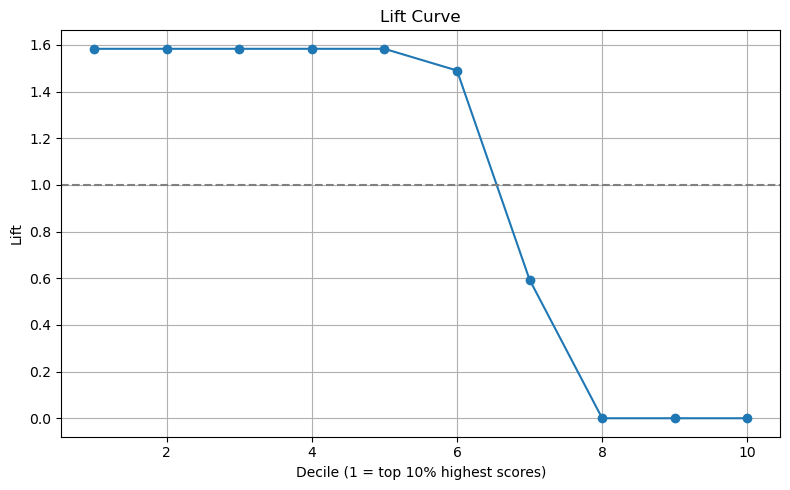

In [22]:
# Wczytanie danych
data = load_breast_cancer()
X = data.data
y = data.target

# Podział danych
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Trenowanie modelu
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predykcja prawdopodobieństw
y_proba = model.predict_proba(X_test)[:, 1]

# Tworzenie DataFrame
df = pd.DataFrame({'y_true': y_test, 'y_score': y_proba})
df.sort_values('y_score', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)

# Obliczanie lift i tworzenie wykresu
def plot_lift_curve(df, n_bins=10):
    df['bucket'] = pd.qcut(df.index, q=n_bins, labels=False)
    grouped = df.groupby('bucket')
    
    lift = []
    baseline = df['y_true'].mean()
    for i in range(n_bins):
        group = grouped.get_group(i)
        lift_i = group['y_true'].mean() / baseline
        lift.append(lift_i)

    # Rysowanie wykresu
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, n_bins + 1), lift, marker='o')
    plt.axhline(1.0, color='gray', linestyle='--')
    plt.title('Lift Curve')
    plt.xlabel('Decile (1 = top 10% highest scores)')
    plt.ylabel('Lift')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_lift_curve(df)

**Interpretacja**:

* Widać wyraźnie, że model najlepiej identyfikuje przypadki pozytywne w pierwszych decylach (najwyższe prawdopodobieństwa), co świadczy o jego dobrej jakości.

I przykład kilku modeli:

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier

In [24]:
# Definicja modeli
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Dummy (losowy)': DummyClassifier(strategy='uniform', random_state=42)
}

In [25]:
# Funkcja do obliczania lift
def compute_lift_curve(model, X_train, y_train, X_test, y_test, n_bins=10):
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())  # normalizacja

    df = pd.DataFrame({'y_true': y_test, 'y_score': y_proba})
    df.sort_values('y_score', ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)
    df['bucket'] = pd.qcut(df.index, q=n_bins, labels=False)
    grouped = df.groupby('bucket')
    
    lift = []
    baseline = df['y_true'].mean()
    for i in range(n_bins):
        group = grouped.get_group(i)
        lift_i = group['y_true'].mean() / baseline
        lift.append(lift_i)
    return lift

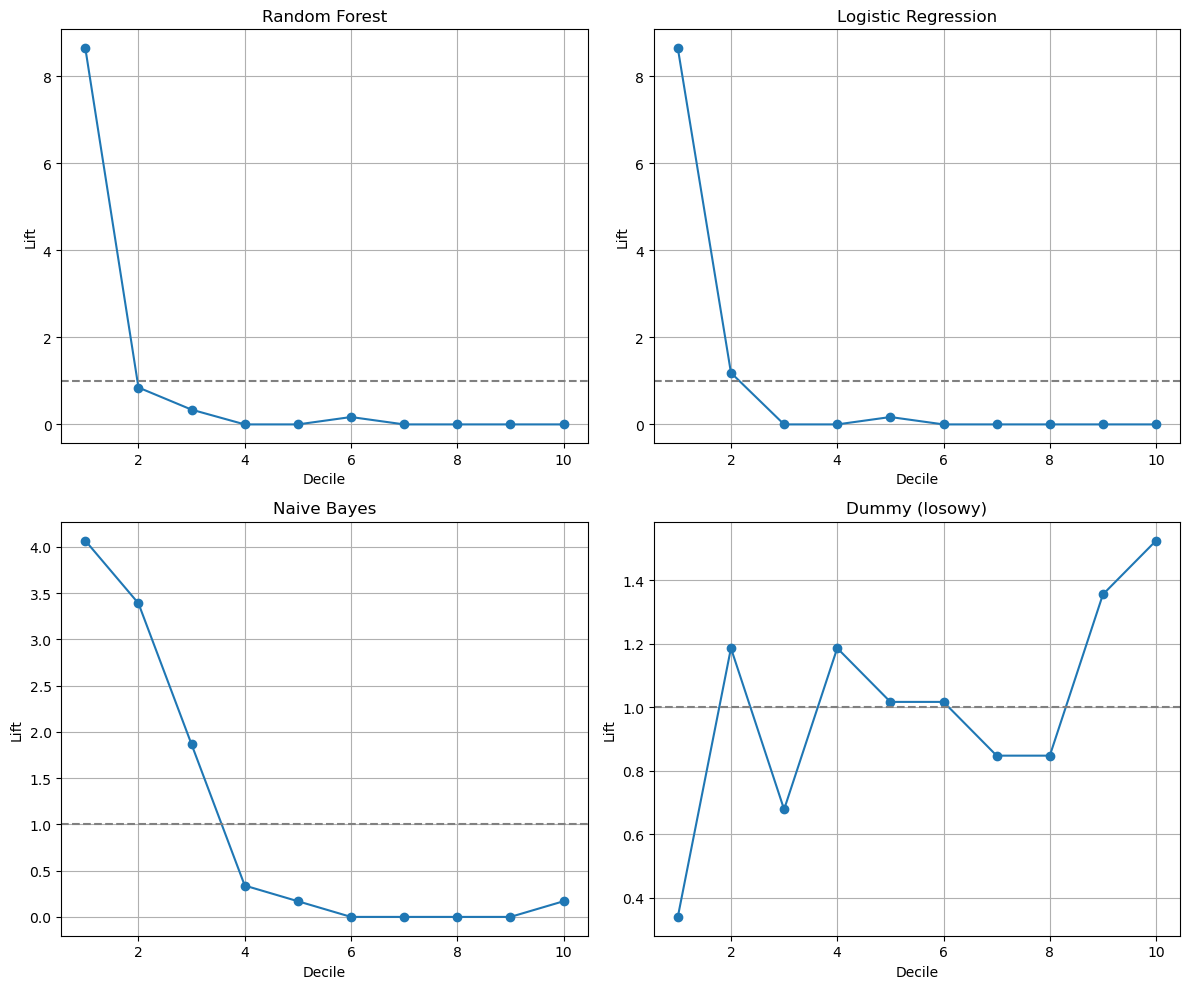

In [26]:
from sklearn.datasets import load_digits

# Wczytanie prawdziwego zbioru danych – np. cyfry (binary classification: cyfra 9 vs reszta)
digits = load_digits()
X_real = digits.data
y_real = (digits.target == 9).astype(int)  # klasyfikacja: 9 vs nie-9 (dane niezbalansowane)

# Podział danych
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=0.3, random_state=42)

# Trening i rysowanie krzywych lift dla czterech modeli
plt.figure(figsize=(12, 10))
for idx, (name, model) in enumerate(models.items(), start=1):
    lift = compute_lift_curve(model, X_train_real, y_train_real, X_test_real, y_test_real)
    plt.subplot(2, 2, idx)
    plt.plot(range(1, 11), lift, marker='o')
    plt.axhline(1.0, color='gray', linestyle='--')
    plt.title(f'{name}')
    plt.xlabel('Decile')
    plt.ylabel('Lift')
    plt.grid(True)

plt.tight_layout()
plt.show()


# Krzywa skumulowanego zysku (Cumulative Gain Curve)

**Cumulative Gain Curve** (*krzywa skumulowanego zysku*) to narzędzie oceny jakości klasyfikatorów binarnych – podobne do krzywej lift – ale zamiast względnej poprawy (lift), pokazuje **bezpośrednio skumulowany udział poprawnie sklasyfikowanych przypadków pozytywnych** w miarę przeglądania coraz większej części próbek posortowanych według prawdopodobieństwa.

---

### **Jak działa:**

1. Model przypisuje każdej obserwacji prawdopodobieństwo bycia klasą pozytywną.
2. Obserwacje są sortowane malejąco wg tego prawdopodobieństwa.
3. Oblicza się, jaki procent rzeczywistych przypadków pozytywnych udało się uchwycić, przeglądając kolejne porcje danych (np. 10%, 20%, …, 100%).
4. Wykres przedstawia:

   * Oś X: odsetek danych przeglądniętych (np. top 10%, 20%, …).
   * Oś Y: skumulowany odsetek poprawnie zidentyfikowanych pozytywnych przypadków.

---

### **Interpretacja:**

* Linia przekątna (baseline) – model losowy (np. 20% danych → 20% przypadków pozytywnych).
* Krzywa powyżej linii przekątnej – model skuteczny.
* Im szybciej krzywa rośnie na początku, tym lepszy model (szybciej „łapie” pozytywne przypadki).

---

### **Przykład:**

Jeśli model w pierwszych 20% obserwacji (tych z najwyższym prawdopodobieństwem) identyfikuje 70% wszystkich przypadków pozytywnych, to oznacza bardzo skuteczne sortowanie.

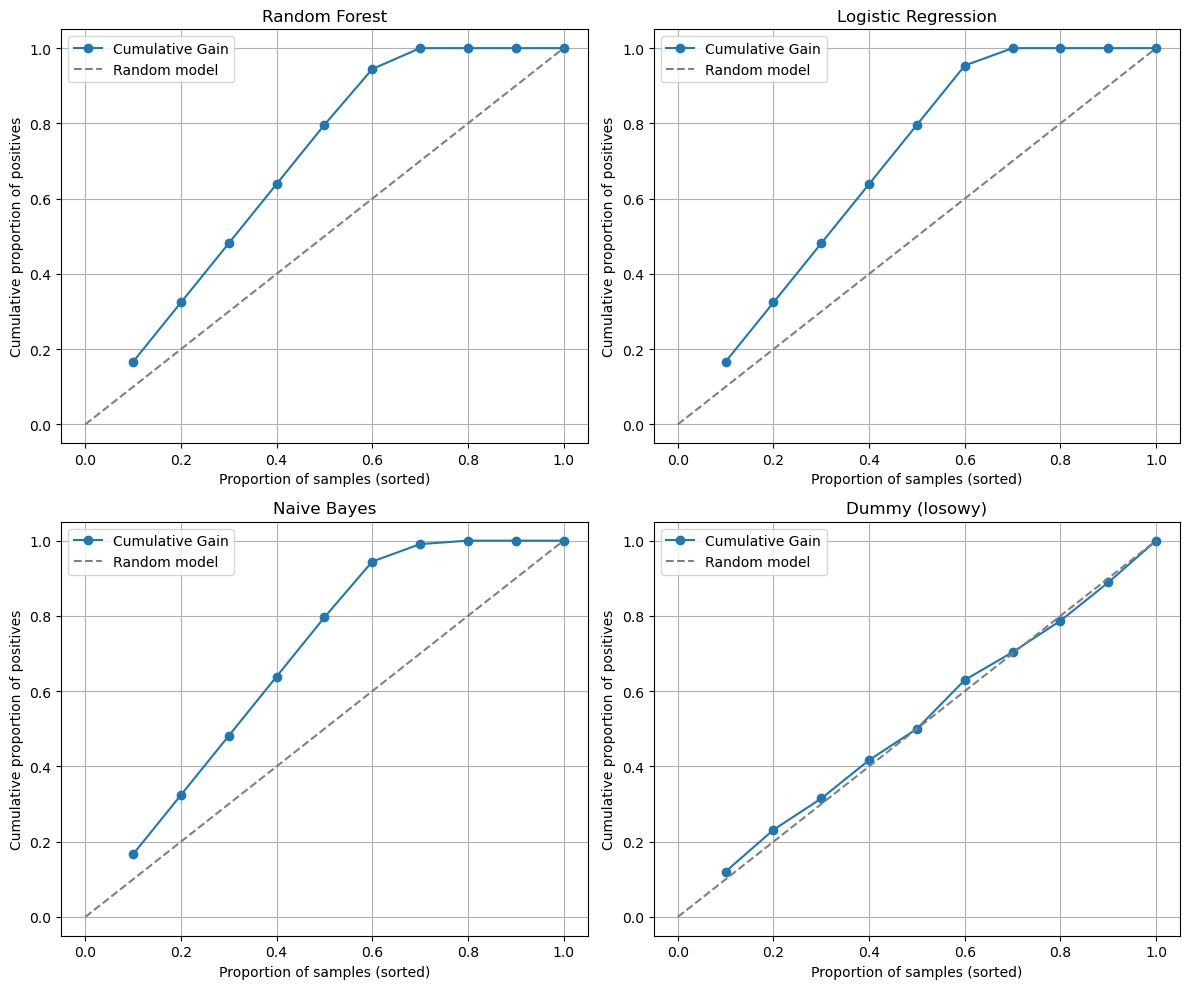

In [27]:
def compute_cumulative_gain(model, X_train, y_train, X_test, y_test, n_bins=10):
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())

    df = pd.DataFrame({'y_true': y_test, 'y_score': y_proba})
    df.sort_values('y_score', ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    df['bucket'] = pd.qcut(df.index, q=n_bins, labels=False)
    grouped = df.groupby('bucket')

    gain = []
    total_positives = df['y_true'].sum()
    cum_tp = 0
    for i in range(n_bins):
        group = grouped.get_group(i)
        cum_tp += group['y_true'].sum()
        gain.append(cum_tp / total_positives)
    return gain

# Rysowanie krzywych cumulative gain
plt.figure(figsize=(12, 10))
for idx, (name, model) in enumerate(models.items(), start=1):
    gain = compute_cumulative_gain(model, X_train, y_train, X_test, y_test)
    plt.subplot(2, 2, idx)
    plt.plot(np.linspace(0.1, 1.0, 10), gain, marker='o', label='Cumulative Gain')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random model')
    plt.title(f'{name}')
    plt.xlabel('Proportion of samples (sorted)')
    plt.ylabel('Cumulative proportion of positives')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

# Dodatek (pipeline - wizualizacja)

W uczeniu maszynowym (ML) pipeline (czyli potok) to sekwencja kroków przetwarzania danych, która łączy różne etapy analizy w jedną, uporządkowaną całość. Celem jest uproszczenie i automatyzacja procesu od surowych danych do końcowego modelu predykcyjnego.

Typowe etapy w ML pipeline to:

* Wczytanie danych – np. z pliku CSV.
* Czyszczenie danych – np. usuwanie braków.
* Transformacja danych – np. standaryzacja, kodowanie zmiennych kategorycznych.
* Trenowanie modelu – np. regresja logistyczna, drzewa decyzyjne.
* Walidacja i testowanie – ocena jakości modelu.

Pipeline zapewnia, że te same transformacje są stosowane w trakcie treningu i testowania — co jest kluczowe dla poprawnych wyników.

W scikit-learn przykładowy pipeline może wyglądać tak:

In [28]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn import set_config

In [29]:
# 1. Wczytanie danych
iris = load_iris()
X = iris.data
y = iris.target

# 2. Podział na zbiory treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Definicja pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),            # Standaryzacja cech
    ('pca', PCA(n_components=2)),            # Redukcja do 2 wymiarów
    ('clf', LogisticRegression())            # Klasyfikator
])

# 4. Trenowanie modelu
pipeline.fit(X_train, y_train)

# 5. Predykcja i ocena
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.91      0.77      0.83        13
   virginica       0.80      0.92      0.86        13

    accuracy                           0.91        45
   macro avg       0.90      0.90      0.90        45
weighted avg       0.92      0.91      0.91        45



Pipeline można równiez wizualizować:

In [30]:
# set_config(display='diagram') # domyślnie
pipeline

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('clf', LogisticRegression())])

In [31]:
# Można też przedstawić potok z wykorzystaniem tekstu
set_config(display='text')  
pipeline

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('clf', LogisticRegression())])

Więcej przykładów:
* https://scikit-learn.org/stable/auto_examples/ensemble/plot_stack_predictors.html#sphx-glr-auto-examples-ensemble-plot-stack-predictors-py 